In [47]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [48]:
# Load the dataset

path_1 ="data/financial_impact.csv"
path_2 ="data/incidents_master.csv"
path_3 ="data/market_impact.csv"
data_finan = pd.read_csv(path_1)
data_incident = pd.read_csv(path_2)
data_market = pd.read_csv(path_3)

In [49]:
df = pd.merge(data_finan, data_incident, on='incident_id')
df_final = pd.merge(df, data_market, on='incident_id', how = "outer")
df_final

,incident_id,direct_loss_usd,direct_loss_method,ransom_demanded_usd,ransom_paid_usd,ransom_source,recovery_cost_usd,legal_fees_usd,regulatory_fine_usd,insurance_payout_usd,...,p_value_30d,earnings_announcement_within_7d,market_cap_at_disclosure,volume_ratio_disclosure,pre_incident_volatility_30d,post_incident_volatility_30d,days_to_price_recovery,notes,created_at,updated_at
0,2021-0101-001,4967279.14,disclosed,9698485.95,5717211.61,company statement,2488838.05,1127543.48,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-0109-001,2066546.90,estimated,NaN,NaN,NaN,1829572.96,600867.65,NaN,1678410.68,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-0111-001,1600000.00,calculated,NaN,NaN,NaN,584549.71,406861.16,NaN,564566.39,...,1.00000,False,3.861498e+09,2.3269,0.020707,0.031208,49.0,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
3,2021-0117-001,2827335.54,calculated,2193976.56,1738883.24,blockchain analysis,2387941.53,474124.37,NaN,NaN,...,0.85785,False,1.378666e+09,2.7503,0.030143,0.034480,325.0,Elevated options activity detected 10 days bef...,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
4,2021-0120-001,78022211.29,disclosed,1397414.98,804045.32,blockchain analysis,44863921.70,21170665.28,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
802,2025-1226-001,5119285.75,disclosed,NaN,NaN,NaN,3553590.95,1633789.43,NaN,2543920.34,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
803,2025-1226-002,4760046.30,calculated,108866.54,NaN,NaN,4843245.47,362343.15,302251.9,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
804,2025-1227-001,43536609.85,estimated,NaN,NaN,NaN,42245003.39,8910659.60,NaN,47202487.06,...,1.00000,False,3.164782e+10,2.5244,0.010872,0.020354,144.0,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
805,2025-1231-001,9944830.62,disclosed,93173.95,NaN,NaN,10655366.28,896669.47,NaN,7135514.59,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [50]:
print("Finance Data", data_finan.shape)
print("Incident Data", data_incident.shape)
print("Market Data", data_market.shape)

print("Merge Data", df_final.shape)

Finance Data (778, 19)
Incident Data (850, 32)
Market Data (358, 31)
Merge Data (807, 80)


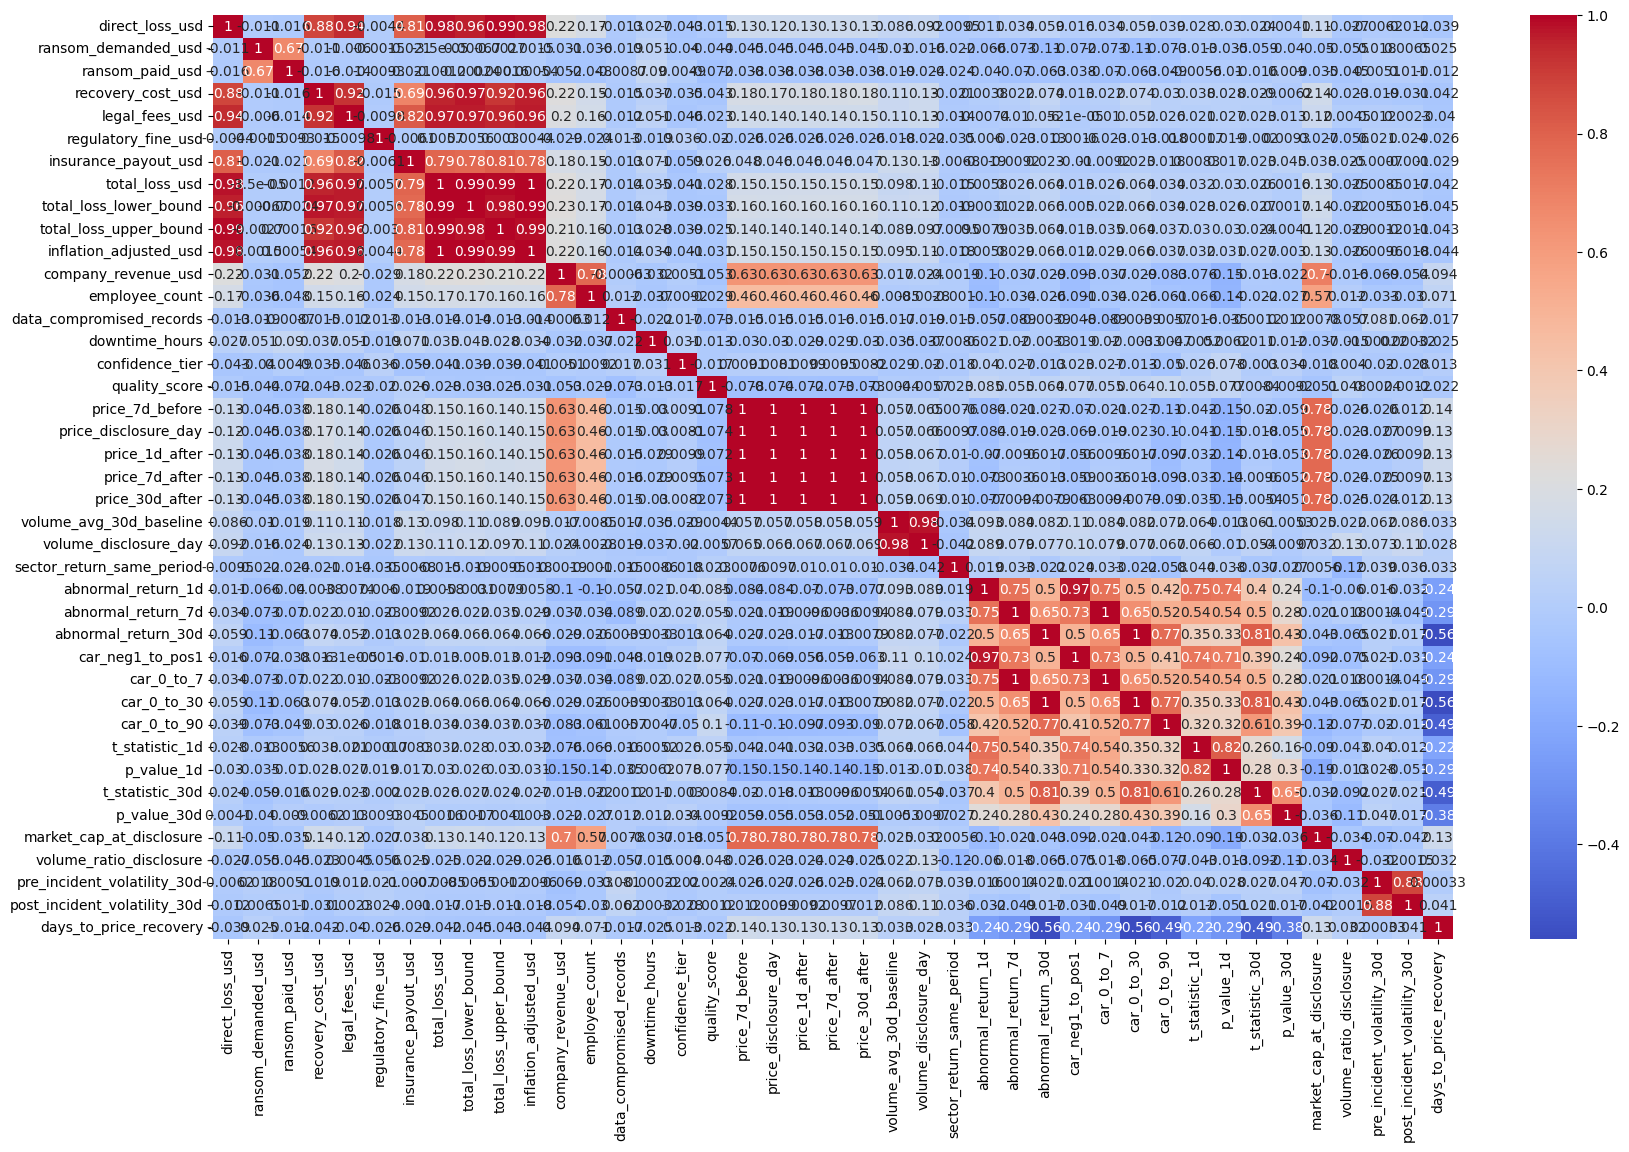

In [51]:
plt.figure(figsize=(20, 12))


import seaborn as sns
num_columns = df_final.select_dtypes(include=['number']).columns
cat_columns = df_final.select_dtypes(include=['object']).columns
df_final[num_columns] = df_final[num_columns].fillna(df_final[num_columns].median())
corr_matrix = df_final[num_columns].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

plt.show()

In [52]:
corr_matrix.sort_values(by = "days_to_price_recovery", ascending = False)

,direct_loss_usd,ransom_demanded_usd,ransom_paid_usd,recovery_cost_usd,legal_fees_usd,regulatory_fine_usd,insurance_payout_usd,total_loss_usd,total_loss_lower_bound,total_loss_upper_bound,...,car_0_to_90,t_statistic_1d,p_value_1d,t_statistic_30d,p_value_30d,market_cap_at_disclosure,volume_ratio_disclosure,pre_incident_volatility_30d,post_incident_volatility_30d,days_to_price_recovery
days_to_price_recovery,-0.039216,0.025229,-0.012300,-0.041891,-0.040345,-0.025539,-0.028809,-0.041877,-0.044599,-0.043015,...,-0.487512,-0.221826,-0.287899,-0.492986,-0.381819,0.134381,0.032060,0.000330,0.040701,1.000000
price_7d_before,0.126863,-0.045445,-0.037848,0.177017,0.144983,-0.025915,0.048439,0.149998,0.160669,0.142669,...,-0.108593,-0.042202,-0.152013,-0.020176,-0.059267,0.778640,-0.025922,-0.026183,0.011701,0.141131
market_cap_at_disclosure,0.111413,-0.049670,-0.035153,0.144831,0.117268,-0.027022,0.037744,0.126612,0.136964,0.120502,...,-0.120496,-0.089652,-0.191161,-0.031959,-0.036419,1.000000,-0.034072,-0.069936,-0.041849,0.134381
price_disclosure_day,0.124121,-0.044888,-0.037933,0.174474,0.142200,-0.025811,0.045974,0.147237,0.157669,0.139963,...,-0.102095,-0.040937,-0.151466,-0.017960,-0.055467,0.777281,-0.022763,-0.026727,0.009893,0.133327
price_1d_after,0.125822,-0.045203,-0.037998,0.176447,0.143109,-0.025859,0.046161,0.148993,0.159275,0.141878,...,-0.097149,-0.031586,-0.141776,-0.012744,-0.053205,0.775854,-0.024234,-0.025806,0.009176,0.130893
price_7d_after,0.126065,-0.045360,-0.038123,0.176204,0.143371,-0.025876,0.045710,0.149070,0.159461,0.142176,...,-0.092942,-0.032726,-0.143580,-0.009620,-0.052490,0.777498,-0.023788,-0.025073,0.009712,0.130283
price_30d_after,0.127497,-0.045314,-0.038039,0.179161,0.145650,-0.026214,0.046786,0.151186,0.161846,0.143970,...,-0.089618,-0.035447,-0.147415,-0.005436,-0.050590,0.776199,-0.024690,-0.024052,0.011509,0.125272
company_revenue_usd,0.217939,-0.031417,-0.051565,0.223568,0.204496,-0.028800,0.175663,0.223715,0.230814,0.214110,...,-0.082551,-0.076391,-0.145653,-0.013325,-0.022296,0.702352,-0.016337,-0.069350,-0.054231,0.094003
employee_count,0.169204,-0.036170,-0.048046,0.151263,0.157986,-0.023678,0.147771,0.165419,0.168316,0.164588,...,-0.061326,-0.066382,-0.140321,-0.022165,-0.026811,0.574442,0.011863,-0.033316,-0.030416,0.070709
post_incident_volatility_30d,-0.012311,0.006483,0.011403,-0.031146,0.002253,0.023511,-0.000999,-0.017390,-0.014702,-0.010917,...,-0.012040,0.012022,-0.050748,0.021450,0.016511,-0.041849,-0.001515,0.884126,1.000000,0.040701


In [53]:
# list of columns to drop based on correlation analysis
cols_to_drop = [
    # redundant loss-related features
    "direct_loss_usd",
    "recovery_cost_usd",
    "legal_fees_usd",
    "total_loss_lower_bound",
    "total_loss_upper_bound",
    "inflation_adjusted_usd",

    # volatility duplication
    "post_incident_volatility_30d",

    # redundant price columns
    "price_7d_before",
    "price_disclosure_day",   # keep this if you prefer, otherwise remove others
    "price_1d_after",
    "price_7d_after",
    "price_30d_after",

    # duplicate abnormal return metrics
    "abnormal_return_1d",
    "abnormal_return_7d",
    "abnormal_return_30d",

    # statistical noise (not useful for ML models)
    "p_value_1d",
    "p_value_30d",
    "t_statistic_1d",
    "t_statistic_30d"
]

# drop columns safely (ignore errors if any column is missing)
df_final = df_final.drop(columns=cols_to_drop, errors='ignore')

# check result
print("Remaining columns:", df_final.columns.tolist())
print("Shape after cleanup:", df_final.shape)

Remaining columns: ['incident_id', 'direct_loss_method', 'ransom_demanded_usd', 'ransom_paid_usd', 'ransom_source', 'regulatory_fine_usd', 'insurance_payout_usd', 'total_loss_usd', 'total_loss_method', 'cpi_index_used', 'notes_x', 'created_at_x', 'updated_at_x', 'company_name', 'company_revenue_usd', 'country_hq', 'industry_primary', 'industry_secondary', 'employee_count', 'is_public_company', 'stock_ticker_x', 'incident_date', 'incident_date_estimated', 'discovery_date', 'disclosure_date', 'attack_vector_primary', 'attack_vector_secondary', 'attack_chain', 'attributed_group', 'attribution_confidence', 'data_compromised_records', 'data_type', 'systems_affected', 'downtime_hours', 'data_source_primary', 'data_source_secondary', 'data_source_type', 'confidence_tier', 'quality_score', 'quality_grade', 'review_flag', 'notes_y', 'created_at_y', 'updated_at_y', 'stock_ticker_y', 'volume_avg_30d_baseline', 'volume_disclosure_day', 'sector_index', 'sector_return_same_period', 'car_neg1_to_pos1

In [54]:
for col in cat_columns:
    print(col, df_final[col].nunique())

incident_id 807
direct_loss_method 3
ransom_source 6
total_loss_method 3
cpi_index_used 5
notes_x 143
created_at_x 1
updated_at_x 1
company_name 693
country_hq 38
industry_primary 20
industry_secondary 19
is_public_company 2
stock_ticker_x 334
incident_date 642
incident_date_estimated 2
discovery_date 635
disclosure_date 645
attack_vector_primary 9
attack_vector_secondary 9
attack_chain 9
attributed_group 31
attribution_confidence 4
data_type 6
systems_affected 582
data_source_primary 778
data_source_secondary 352
data_source_type 5
quality_grade 3
review_flag 2
notes_y 60
created_at_y 1
updated_at_y 1
stock_ticker_y 317
sector_index 10
earnings_announcement_within_7d 2
notes 24
created_at 1
updated_at 1


In [ ]:
df_final['incident_year'] = pd.to_datetime(df_final['incident_date']).dt.year
df_final['incident_month'] = pd.to_datetime(df_final['incident_date']).dt.month

df_final['disclosure_delay_days'] = (
    pd.to_datetime(df_final['disclosure_date']) - 
    pd.to_datetime(df_final['incident_date'])
).dt.days

df_final['discovery_delay_days'] = (
    pd.to_datetime(df_final['discovery_date']) - 
    pd.to_datetime(df_final['incident_date'])
).dt.days


cols_to_drop = [
    # IDs
    "incident_id",
    "company_name",
    "stock_ticker_x",

    # text
    "notes_x",
    "notes",
    "systems_affected",

    # timestamps
    "created_at_x",
    "updated_at_x",
    "created_at",
    "updated_at",

    # raw dates (after feature engineering)
    "incident_date",
    "discovery_date",
    "disclosure_date"
]

df_final = df_final.drop(columns=cols_to_drop, errors='ignore')

,direct_loss_method,ransom_demanded_usd,ransom_paid_usd,ransom_source,regulatory_fine_usd,insurance_payout_usd,total_loss_usd,total_loss_method,cpi_index_used,company_revenue_usd,...,car_0_to_90,earnings_announcement_within_7d,market_cap_at_disclosure,volume_ratio_disclosure,pre_incident_volatility_30d,days_to_price_recovery,incident_year,incident_month,disclosure_delay_days,discovery_delay_days
0,disclosed,9698485.95,5717211.61,company statement,914151.68,6316200.45,1.430087e+07,estimated,CPI-U 2021 (270.97),1.660296e+08,...,-0.010039,NaN,1.929513e+10,2.7534,0.023608,57.0,2021.0,1.0,26.0,15.0
1,estimated,1979266.18,1129758.67,NaN,914151.68,1678410.68,4.496988e+06,calculated,CPI-U 2021 (270.97),3.455929e+08,...,-0.010039,NaN,1.929513e+10,2.7534,0.023608,57.0,2021.0,1.0,64.0,18.0
2,calculated,1979266.18,1129758.67,NaN,914151.68,564566.39,2.591411e+06,disclosed,CPI-U 2021 (270.97),1.024751e+09,...,0.003527,False,3.861498e+09,2.3269,0.020707,49.0,2021.0,1.0,63.0,12.0
3,calculated,2193976.56,1738883.24,blockchain analysis,914151.68,6316200.45,7.428285e+06,disclosed,CPI-U 2021 (270.97),3.269371e+08,...,-0.034650,False,1.378666e+09,2.7503,0.030143,325.0,2021.0,1.0,59.0,10.0
4,disclosed,1397414.98,804045.32,blockchain analysis,914151.68,6316200.45,1.448608e+08,estimated,CPI-U 2021 (270.97),3.688471e+08,...,-0.010039,NaN,1.929513e+10,2.7534,0.023608,57.0,2021.0,1.0,28.0,16.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
802,disclosed,1979266.18,1129758.67,NaN,914151.68,2543920.34,1.030667e+07,disclosed,CPI-U 2025 (321.5),8.937323e+07,...,-0.010039,NaN,1.929513e+10,2.7534,0.023608,57.0,2025.0,12.0,75.0,60.0
803,calculated,108866.54,1129758.67,NaN,302251.90,6316200.45,1.026789e+07,disclosed,CPI-U 2025 (321.5),2.758048e+09,...,-0.010039,NaN,1.929513e+10,2.7534,0.023608,57.0,2025.0,12.0,74.0,64.0
804,estimated,1979266.18,1129758.67,NaN,914151.68,47202487.06,9.469227e+07,estimated,CPI-U 2025 (321.5),5.411625e+09,...,-0.033981,False,3.164782e+10,2.5244,0.010872,144.0,2025.0,12.0,105.0,93.0
805,disclosed,93173.95,1129758.67,NaN,914151.68,7135514.59,2.149687e+07,calculated,CPI-U 2025 (321.5),2.880927e+08,...,-0.010039,NaN,1.929513e+10,2.7534,0.023608,57.0,2025.0,12.0,45.0,33.0
